Fetching since 2020-01-01 00:00:00 ...
Fetching since 2020-02-11 16:00:00.001000 ...
Fetching since 2020-03-24 14:00:00.001000 ...
Fetching since 2020-05-05 08:00:00.001000 ...
Fetching since 2020-06-16 00:00:00.001000 ...
Fetching since 2020-07-27 19:00:00.001000 ...
Fetching since 2020-09-07 11:00:00.001000 ...
Fetching since 2020-10-19 03:00:00.001000 ...
Fetching since 2020-11-29 19:00:00.001000 ...
Fetching since 2021-01-10 17:00:00.001000 ...
Fetching since 2021-02-21 10:00:00.001000 ...
Fetching since 2021-04-04 03:00:00.001000 ...
Fetching since 2021-05-16 00:00:00.001000 ...
Fetching since 2021-06-26 16:00:00.001000 ...
Fetching since 2021-08-07 08:00:00.001000 ...
Fetching since 2021-09-18 04:00:00.001000 ...
Fetching since 2021-10-29 22:00:00.001000 ...
Fetching since 2021-12-10 14:00:00.001000 ...
Fetching since 2022-01-21 06:00:00.001000 ...
Fetching since 2022-03-03 22:00:00.001000 ...
Fetching since 2022-04-14 14:00:00.001000 ...
Fetching since 2022-05-26 06:00:00.001000

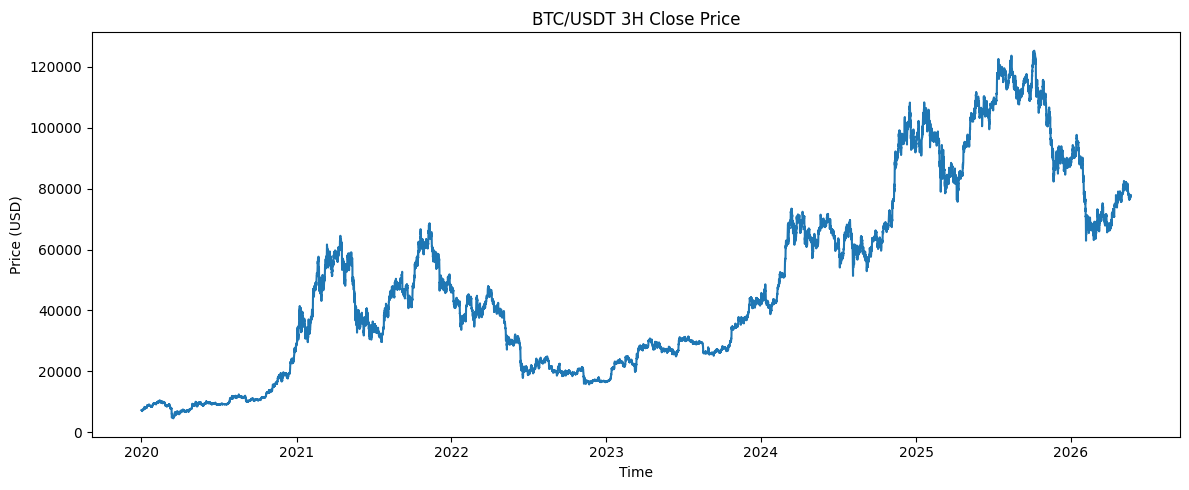

Plot saved → bitcoin_data/plots/btc_plot.png


In [3]:
import time
import ccxt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ── folders ─────────────────────────────────────────────
Path("bitcoin_data/raw").mkdir(parents=True, exist_ok=True)
Path("bitcoin_data/plots").mkdir(parents=True, exist_ok=True)

OHLCV_COLS = ["open", "high", "low", "close", "volume"]

# ─────────────────────────────────────────────────────────
# 1. FETCH FULL HISTORICAL DATA (BINANCE)
# ─────────────────────────────────────────────────────────
def fetch_binance_full(symbol="BTC/USDT", timeframe="1h", since=None, limit=1000):
    exchange = ccxt.binance({"enableRateLimit": True})

    all_data = []

    if since is None:
        # default: start ~5 years ago
        since = exchange.parse8601("2020-01-01T00:00:00Z")

    while True:
        print(f"Fetching since {pd.to_datetime(since, unit='ms')} ...")

        ohlcv = exchange.fetch_ohlcv(
            symbol=symbol,
            timeframe=timeframe,
            since=since,
            limit=limit
        )

        if not ohlcv:
            break

        all_data += ohlcv
        since = ohlcv[-1][0] + 1  # move forward

        time.sleep(exchange.rateLimit / 1000)

        # stop condition if last batch is small
        if len(ohlcv) < limit:
            break

    df = pd.DataFrame(all_data, columns=[
        "timestamp", "open", "high", "low", "close", "volume"
    ])

    df["datetime"] = pd.to_datetime(df["timestamp"], unit="ms")
    df.set_index("datetime", inplace=True)
    df.drop(columns=["timestamp"], inplace=True)

    return df


# ─────────────────────────────────────────────────────────
# 2. CLEANING PIPELINE
# ─────────────────────────────────────────────────────────
def enforce_schema(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = [c.lower().strip() for c in df.columns]

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    if df.index.tz is not None:
        df.index = df.index.tz_localize(None)

    df.sort_index(inplace=True)
    df = df[~df.index.duplicated(keep="first")]

    df = df[df["close"] > 0].dropna(subset=["close"])

    df[OHLCV_COLS] = df[OHLCV_COLS].ffill()

    return df


# ─────────────────────────────────────────────────────────
# 3. RESAMPLE TO 3H
# ─────────────────────────────────────────────────────────
def resample_to_3h(df):
    return df.resample("3h").agg({
        "open": "first",
        "high": "max",
        "low": "min",
        "close": "last",
        "volume": "sum"
    }).dropna()


# ─────────────────────────────────────────────────────────
# 4. PRINT SUMMARY
# ─────────────────────────────────────────────────────────
def print_summary(df, label):
    print(
        f"[{label}] rows={len(df):,} | "
        f"{df.index.min()} → {df.index.max()} | "
        f"min=${df['close'].min():,.0f} | max=${df['close'].max():,.0f}"
    )


# ─────────────────────────────────────────────────────────
# 5. SAVE CSV
# ─────────────────────────────────────────────────────────
def save_csv(df, name):
    path = f"bitcoin_data/raw/{name}"
    df.to_csv(path)
    print(f"Saved → {path}")


# ─────────────────────────────────────────────────────────
# 6. SIMPLE PLOT
# ─────────────────────────────────────────────────────────
def plot_close(df, title="BTC Price"):
    plt.figure(figsize=(12, 5))
    plt.plot(df.index, df["close"])
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Price (USD)")
    plt.tight_layout()

    path = "bitcoin_data/plots/btc_plot.png"
    plt.savefig(path)
    plt.show()

    print(f"Plot saved → {path}")


# ─────────────────────────────────────────────────────────
# 7. MAIN PIPELINE
# ─────────────────────────────────────────────────────────
def main():
    # STEP 1: FETCH
    df = fetch_binance_full()

    # STEP 2: CLEAN
    df = enforce_schema(df)

    # STEP 3: RESAMPLE
    df_3h = resample_to_3h(df)

    # STEP 4: CHECKS
    print_summary(df, "1H RAW")
    print_summary(df_3h, "3H")

    # STEP 5: SAVE
    save_csv(df, "btc_1h.csv")
    save_csv(df_3h, "btc_3h.csv")

    # STEP 6: PLOT
    plot_close(df_3h, "BTC/USDT 3H Close Price")


if __name__ == "__main__":
    main()